# Are the Regimes Separable?

**Author**: Jakob Balkovec
**Date**: 2026-04-15

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
TRAIN_PATH = "/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/train.csv"
VAL_PATH   = "/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/val.csv"
TEST_PATH  = "/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_8.0/test.csv"

T1, T2 = 0.20, 0.313
TARGET_COL = "soil_moisture_5cm"
REGIME_NAMES  = {0: "Dry", 1: "Transition", 2: "Wet"}
REGIME_COLORS = {0: "#E07B39", 1: "#6B9AC4", 2: "#4CAF50"}


train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

In [9]:
def assign_regime(y, t1=T1, t2=T2):
    y_arr = np.asarray(y).ravel()
    reg = np.zeros_like(y_arr, dtype=int)
    reg[(y_arr > t1) & (y_arr <= t2)] = 1
    reg[y_arr > t2] = 2
    return reg

In [10]:
FEATURE_COLS_TRANSITION = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",

    "SMAP_sm_interp_lag1",
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollmean7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",
    "V_ema_G_API_kobs7",
    "V_ema_G_API_kobs14",
    "V_ema_G_API_kobs30",
    "V_rollmean_G_API_kobs7",
    "V_rollmean_G_API_kobs14",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs14",
    "V_ema_LST_modis_kobs7",
    "A_d_LST_modis_kobs14",
    "V_rollmin_LST_modis_kobs30",
    "V_rollmean_s2_b11_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "API_x_year", "SMAP_x_year",
    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",
]

FEATURE_COLS_DRY = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_sm_interp_diff1",
    "A_d_SMAP_sm_interp_kobs14",

    "V_ema_LST_modis_kobs7",
    "V_rollmin_LST_modis_kobs30",
    "A_d_LST_modis_kobs14",

    "slope", "elev",
    "K_slope_sin", "K_slope_cos", "K_aspect_cos",
    "J_clay_wfrac_b0", "J_sand_wfrac_b0",

    "G_API",
    "V_ema_G_API_kobs14",
    "C_lag_G_API_kobs1",

    "G_DSLR",

    "V_rollmean_s2_b11_kobs7",
    "year_frac", "sin_year", "cos_year",
]

FEATURE_COLS_WET = [
    "SMAP_sm_interp_diff1",
    "SMAP_sm_interp_rollstd7",
    "SMAP_sm_interp_rollrange7",
    "SMAP_sm_interp_pctchg",
    "A_d_SMAP_sm_interp_kobs7",
    "A_grad_SMAP_sm_interp_kobs7",
    "A_pct_SMAP_sm_interp",

    "SMAP_sm_interp_lag7",

    "G_API",
    "G_rain_sum_3d",
    "G_rain_sum_7d",

    "G_rain_sum_30d",

    "V_rollstd_G_API_kobs7",
    "V_rollcv_G_API_kobs7",
    "A_d_G_API_kobs7",

    "A_d_E_SAR_diff_kobs1",
    "A_d_E_SAR_diff_kobs7",
    "A_grad_E_SAR_diff_kobs7",
    "A_grad_E_SAR_ratio_kobs7",
    "V_rollstd_E_SAR_diff_kobs7",
    "V_rollstd_E_SAR_ratio_kobs7",

    "V_rollstd_F_NDMI_kobs7",
    "A_d_F_NDMI_kobs7",

    "year_frac", "sin_year", "cos_year",
    "slope", "elev",
]

In [11]:
SHARED_FEATURES = sorted(set(FEATURE_COLS_DRY) | set(FEATURE_COLS_TRANSITION) | set(FEATURE_COLS_WET))

all_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)
all_df["regime"] = assign_regime(all_df[TARGET_COL])

X_all = all_df[SHARED_FEATURES].copy()
y_reg = all_df["regime"].values
y_sm  = all_df[TARGET_COL].values

valid = np.isfinite(X_all.values).all(axis=1)
X_all  = X_all[valid].reset_index(drop=True)
y_reg  = y_reg[valid]
y_sm   = y_sm[valid]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print(f"Shared feature space: {X_scaled.shape[1]} features, {X_scaled.shape[0]} samples")
print("Regime counts:", {REGIME_NAMES[k]: int((y_reg == k).sum()) for k in [0,1,2]})

Shared feature space: 53 features, 12037 samples
Regime counts: {'Dry': 4784, 'Transition': 5380, 'Wet': 1873}


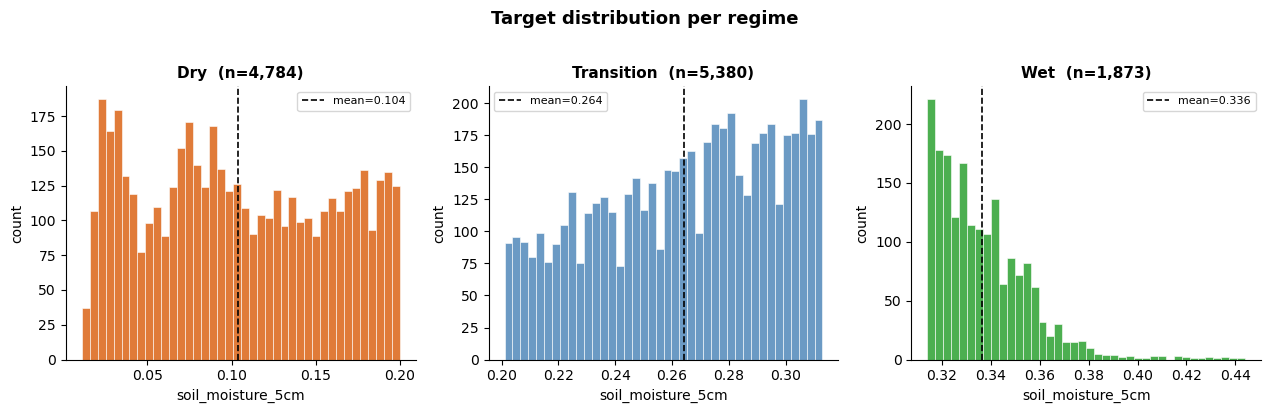

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

for ax, (r, name) in zip(axes, REGIME_NAMES.items()):
    vals = y_sm[y_reg == r]
    ax.hist(vals, bins=40, color=REGIME_COLORS[r], edgecolor="white", linewidth=0.4)
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.3f}")
    ax.set_title(f"{name}  (n={len(vals):,})", fontsize=11, fontweight="bold")
    ax.set_xlabel("soil_moisture_5cm")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Target distribution per regime", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

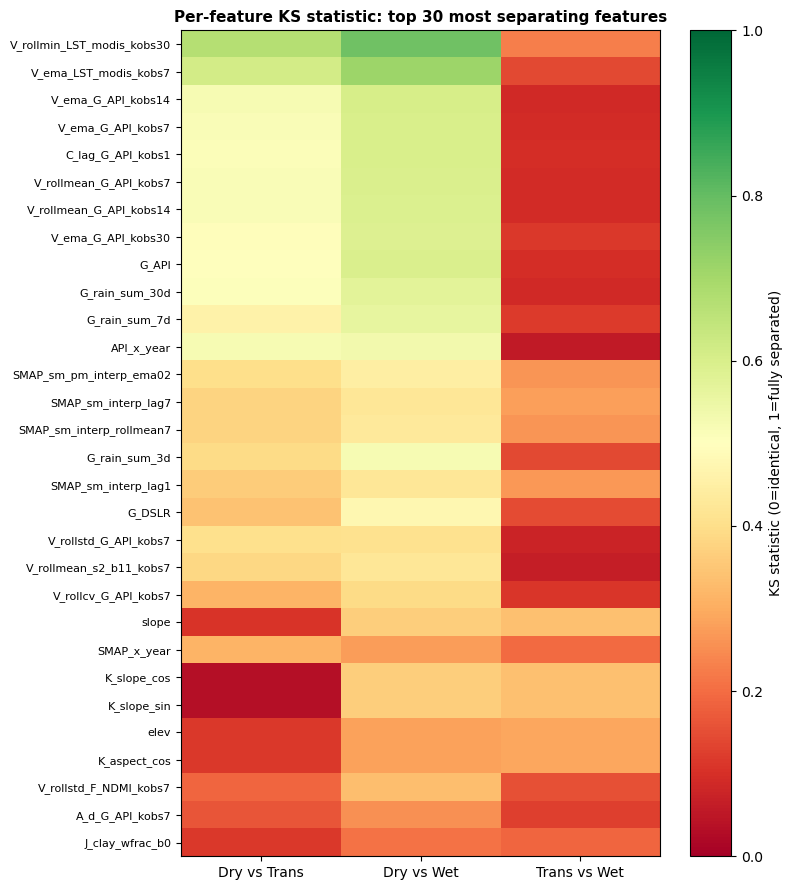


Top 10 most separating features (mean KS across pairs):
V_rollmin_LST_modis_kobs30    0.561
V_ema_LST_modis_kobs7         0.489
V_ema_G_API_kobs14            0.405
V_ema_G_API_kobs7             0.402
C_lag_G_API_kobs1             0.401
V_rollmean_G_API_kobs7        0.399
V_rollmean_G_API_kobs14       0.399
V_ema_G_API_kobs30            0.399
G_API                         0.399
G_rain_sum_30d                0.389


In [13]:
from scipy.stats import ks_2samp

pairs = [(0,1,"Dry vs Trans"), (0,2,"Dry vs Wet"), (1,2,"Trans vs Wet")]
results = {}

for (ra, rb, label) in pairs:
    Xa = X_scaled[y_reg == ra]
    Xb = X_scaled[y_reg == rb]
    stats, pvals = [], []
    for j in range(X_scaled.shape[1]):
        stat, pval = ks_2samp(Xa[:, j], Xb[:, j])
        stats.append(stat)
        pvals.append(pval)
    results[label] = {"stat": np.array(stats), "pval": np.array(pvals)}

ks_df = pd.DataFrame(
    {label: res["stat"] for label, res in results.items()},
    index=SHARED_FEATURES
)
ks_df["mean_ks"] = ks_df.mean(axis=1)
ks_df = ks_df.sort_values("mean_ks", ascending=False)

top_feats = ks_df.head(30)
fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(top_feats[["Dry vs Trans","Dry vs Wet","Trans vs Wet"]].values,
               aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks([0,1,2])
ax.set_xticklabels(["Dry vs Trans","Dry vs Wet","Trans vs Wet"], fontsize=10)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats.index, fontsize=8)
plt.colorbar(im, ax=ax, label="KS statistic (0=identical, 1=fully separated)")
ax.set_title("Per-feature KS statistic: top 30 most separating features", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 10 most separating features (mean KS across pairs):")
print(ks_df["mean_ks"].head(10).round(3).to_string())

Computing energy distances (subsampled to 2000 per regime)...
  Dry vs Transition             energy_dist=1.4395  K2-ratio=294.6173
  Dry vs Wet                    energy_dist=1.7796  K2-ratio=722.7467
  Transition vs Wet             energy_dist=0.4058  K2-ratio=167.4186


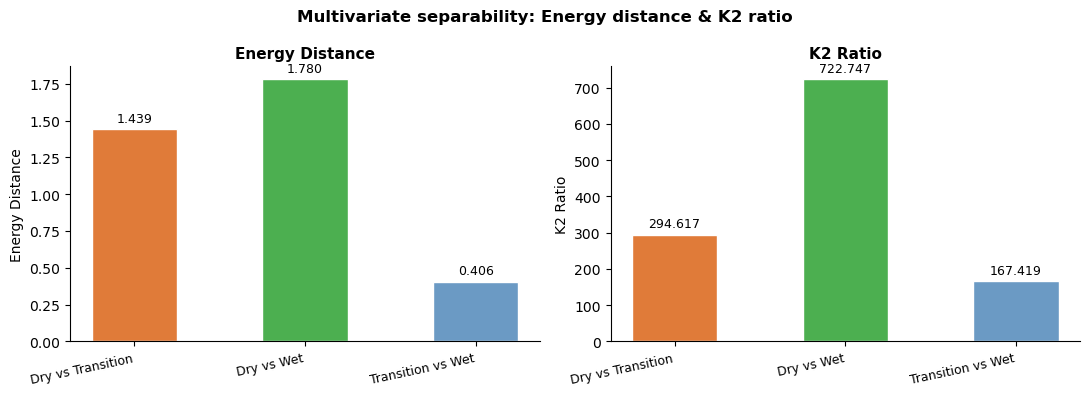

In [14]:
def energy_distance(A, B, subsample=2000, seed=42):
    rng = np.random.default_rng(seed)
    if len(A) > subsample:
        A = A[rng.choice(len(A), subsample, replace=False)]
    if len(B) > subsample:
        B = B[rng.choice(len(B), subsample, replace=False)]

    def mean_dist(P, Q):
        diff = P[:, None, :] - Q[None, :, :]   # (n, m, d)
        return np.sqrt((diff**2).sum(axis=2)).mean()

    e_xy  = mean_dist(A, B)
    e_xx  = mean_dist(A, A)
    e_yy  = mean_dist(B, B)
    return 2*e_xy - e_xx - e_yy

print("Computing energy distances (subsampled to 2000 per regime)...")

pairs_full = [
    (0, 1, "Dry vs Transition"),
    (0, 2, "Dry vs Wet"),
    (1, 2, "Transition vs Wet"),
]

ed_results = {}
for ra, rb, label in pairs_full:
    Xa = X_scaled[y_reg == ra]
    Xb = X_scaled[y_reg == rb]
    ed = energy_distance(Xa, Xb)
    ea = energy_distance(Xa, Xa)
    eb = energy_distance(Xb, Xb)
    k2 = ed / (0.5 * (ea + eb) + 1e-9) if (ea + eb) > 0 else np.inf
    ed_results[label] = {"energy_dist": ed, "k2_ratio": k2}
    print(f"  {label:28s}  energy_dist={ed:.4f}  K2-ratio={k2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = list(ed_results.keys())
ed_vals = [ed_results[l]["energy_dist"] for l in labels]
k2_vals = [ed_results[l]["k2_ratio"]    for l in labels]

colors = ["#E07B39", "#4CAF50", "#6B9AC4"]
for ax, vals, title in zip(axes, [ed_vals, k2_vals], ["Energy Distance", "K2 Ratio"]):
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=3)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylabel(title)

fig.suptitle("Multivariate separability: Energy distance & K2 ratio", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

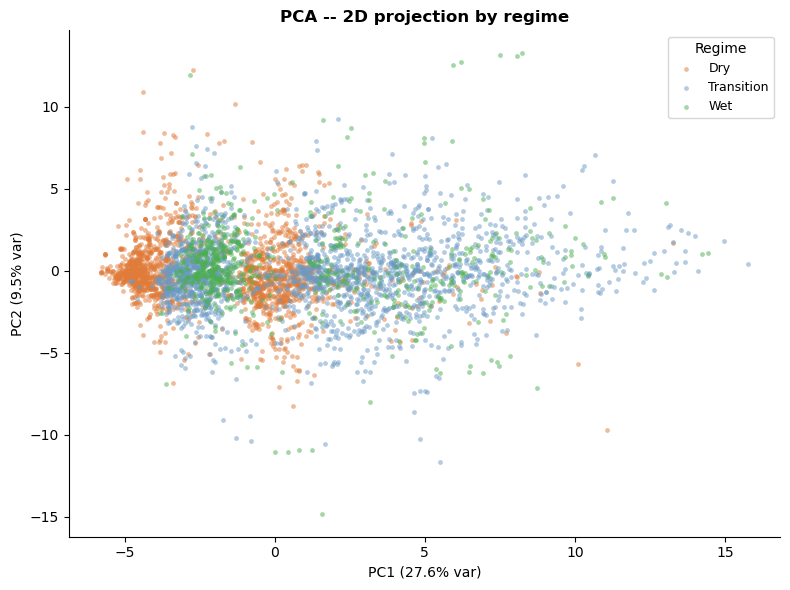

In [15]:
SAMPLE_N = 1500
rng = np.random.default_rng(0)
idx = rng.choice(len(X_scaled), min(SAMPLE_N * 3, len(X_scaled)), replace=False)

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled)
Z_sub = Z_pca[idx]
c_sub = y_reg[idx]

fig, ax = plt.subplots(figsize=(8, 6))
for r, name in REGIME_NAMES.items():
    mask = c_sub == r
    ax.scatter(Z_sub[mask, 0], Z_sub[mask, 1],
               c=REGIME_COLORS[r], label=name, s=12, alpha=0.5, linewidths=0)

var = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)", fontsize=10)
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)", fontsize=10)
ax.set_title("PCA -- 2D projection by regime", fontsize=12, fontweight="bold")
ax.legend(title="Regime", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

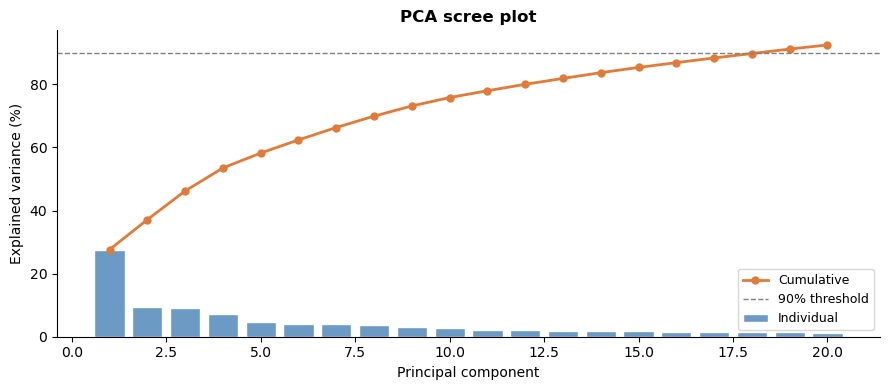

Components needed for 90% variance: 19


In [16]:
pca_full = PCA(n_components=min(20, X_scaled.shape[1]), random_state=42)
pca_full.fit(X_scaled)

ev = pca_full.explained_variance_ratio_
cumev = np.cumsum(ev)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(ev)+1), ev*100, color="#6B9AC4", edgecolor="white", label="Individual")
ax.plot(range(1, len(cumev)+1), cumev*100, "o-", color="#E07B39", linewidth=2, markersize=5, label="Cumulative")
ax.axhline(90, color="gray", linestyle="--", linewidth=1, label="90% threshold")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("PCA scree plot", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

n90 = int(np.searchsorted(cumev, 0.90)) + 1
print(f"Components needed for 90% variance: {n90}")

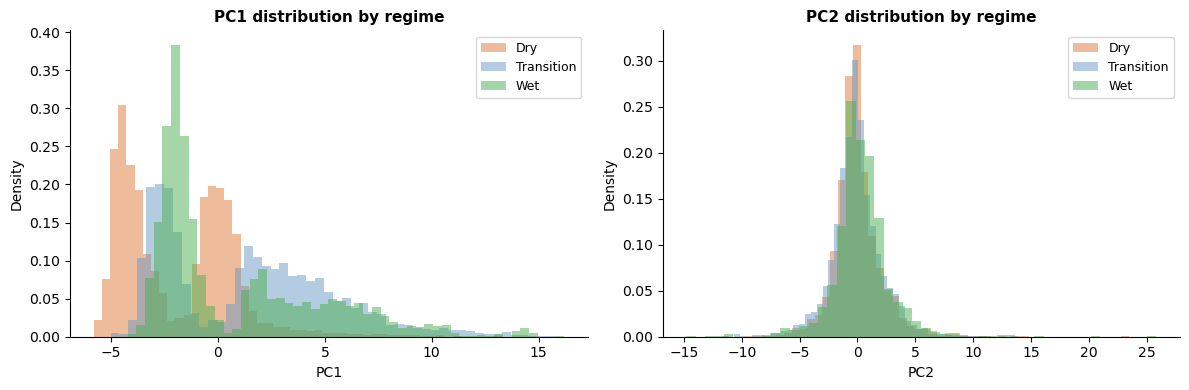

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pc_idx, pc_name in zip(axes, [0, 1], ["PC1", "PC2"]):
    for r, name in REGIME_NAMES.items():
        vals = Z_pca[y_reg == r, pc_idx]
        ax.hist(vals, bins=50, alpha=0.5, color=REGIME_COLORS[r], label=name, density=True)
    ax.set_xlabel(pc_name)
    ax.set_ylabel("Density")
    ax.set_title(f"{pc_name} distribution by regime", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

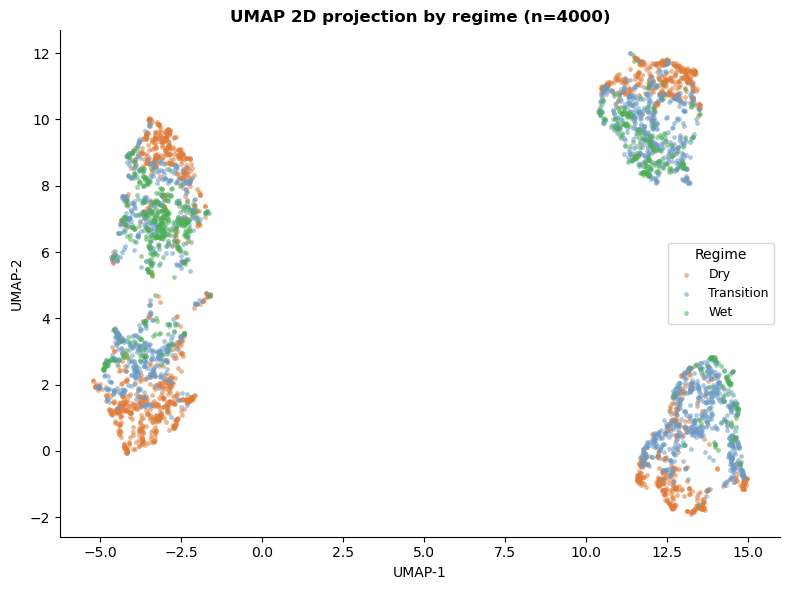

In [18]:
import umap

UMAP_N = 4000

rng = np.random.default_rng(1)
idx_u = rng.choice(len(X_scaled), min(UMAP_N, len(X_scaled)), replace=False)
X_u = X_scaled[idx_u]
c_u = y_reg[idx_u]

reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    metric="euclidean", random_state=42, verbose=False)
Z_umap = reducer.fit_transform(X_u)

fig, ax = plt.subplots(figsize=(8, 6))
for r, name in REGIME_NAMES.items():
    mask = c_u == r
    ax.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
               c=REGIME_COLORS[r], label=name, s=12, alpha=0.55, linewidths=0)

ax.set_xlabel("UMAP-1", fontsize=10)
ax.set_ylabel("UMAP-2", fontsize=10)
ax.set_title(f"UMAP 2D projection by regime (n={UMAP_N})", fontsize=12, fontweight="bold")
ax.legend(title="Regime", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

=== Classifier Probe: Regime Separability ===
              precision    recall  f1-score   support

         Dry       0.92      0.93      0.93       988
  Transition       0.67      0.90      0.77      1156
         Wet       0.75      0.23      0.35       576

    accuracy                           0.77      2720
   macro avg       0.78      0.69      0.68      2720
weighted avg       0.78      0.77      0.74      2720



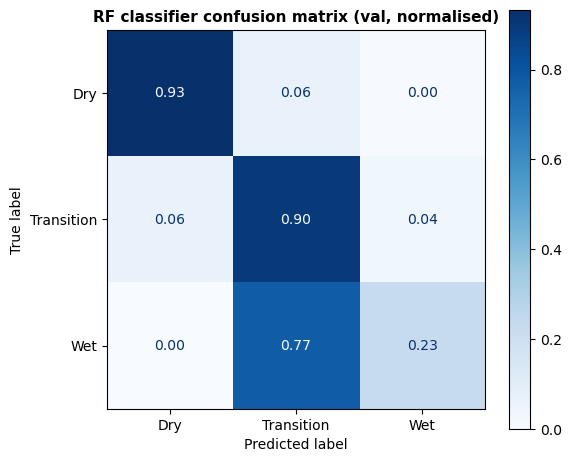

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

train_mask = np.arange(len(train_df))
val_start  = len(train_df)
val_end    = len(train_df) + len(val_df)


all_df_valid = all_df[valid].reset_index(drop=True)
is_train = all_df_valid["date"].isin(train_df["date"]) & all_df_valid["station_id"].isin(train_df["station_id"])
is_val   = all_df_valid["date"].isin(val_df["date"])   & all_df_valid["station_id"].isin(val_df["station_id"])

X_clf_train = X_scaled[is_train.values]
y_clf_train = y_reg[is_train.values]
X_clf_val   = X_scaled[is_val.values]
y_clf_val   = y_reg[is_val.values]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X_clf_train, y_clf_train)
y_pred_clf = rf.predict(X_clf_val)

print("=== Classifier Probe: Regime Separability ===")
print(classification_report(y_clf_val, y_pred_clf,
                             target_names=["Dry","Transition","Wet"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_clf_val, y_pred_clf, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=["Dry","Transition","Wet"])
disp.plot(ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
ax.set_title("RF classifier confusion matrix (val, normalised)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

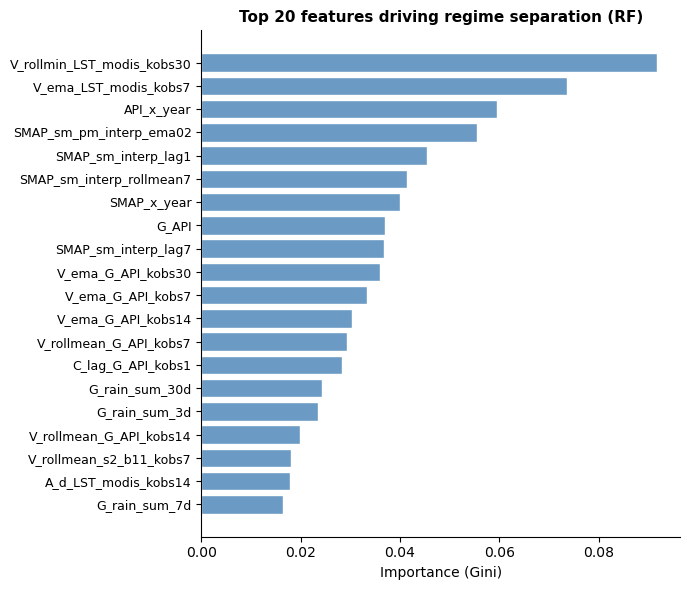

In [20]:
imp = pd.Series(rf.feature_importances_, index=SHARED_FEATURES).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
y_pos = np.arange(len(imp))
ax.barh(y_pos, imp.values, color="#6B9AC4", edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(imp.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Importance (Gini)")
ax.set_title("Top 20 features driving regime separation (RF)", fontsize=11, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()